<a href="https://colab.research.google.com/github/qmafaza/CI-Projek-BOA/blob/main/BOA_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install contextily
!pip install geopandas
!pip install osmnx
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 8.6 MB/s eta 0:00:00


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import contextily as ctx
import geopandas as gpd
from shapely.geometry import box
import osmnx as ox
from PIL import Image
from rasterio.features import rasterize
import rasterio
from rasterio.transform import from_bounds
import requests
import re
import gdown

## Load Data

In [6]:
# The link
link = 'https://drive.google.com/uc?export=download&id=1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ'

# Extract the file ID from the link
match = re.search(r'id=([\w-]+)', link)
file_id = None
if match:
    file_id = match.group(1)
else:
    print("Error: Could not extract file ID from the provided link.")

if file_id:
    # Define the output path for the downloaded CSV
    output_file_name = 'train.csv'

    try:
        # Use gdown to download the file. It automatically handles the 'download anyway' prompt.
        print(f"Attempting to download file ID: {file_id} using gdown...")
        gdown.download(id=file_id, output=output_file_name, quiet=False)
        print(f"Successfully downloaded '{output_file_name}'.")

    except Exception as e:
        print(f"An error occurred during download or loading: {e}")
else:
    print("Cannot proceed without a valid Google Drive file ID.")

Attempting to download file ID: 1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ using gdown...


Downloading...
From (original): https://drive.google.com/uc?id=1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ
From (redirected): https://drive.google.com/uc?id=1BFPKsWIxC2uJ9a1bQANvmRRv1kfC52UJ&confirm=t&uuid=639b3cea-bf2a-489c-9d29-9b251d48f571
To: /content/train.csv
100%|██████████| 651M/651M [01:09<00:00, 9.36MB/s]


Successfully downloaded 'train.csv'.
Successfully loaded 'train.csv' into DataFrame. First 5 rows:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1,1.030764
1,2012-04-08 07:30:50.0000002,5.3,2012-04-08 07:30:50 UTC,-73.996335,40.737142,-73.980721,40.733559,1,1.374577
2,2011-04-05 17:11:05.0000001,7.7,2011-04-05 17:11:05 UTC,-74.001821,40.737547,-73.998060,40.722788,2,1.671445
3,2009-07-22 16:08:00.000000163,5.3,2009-07-22 16:08:00 UTC,-73.981060,40.737690,-73.994177,40.728412,1,1.511904
4,2011-06-28 19:47:00.000000168,4.5,2011-06-28 19:47:00 UTC,-73.988893,40.760160,-73.986445,40.757857,3,0.328771


In [8]:
# read data in pandas dataframe
df_train =  pd.read_csv('./train.csv', nrows = 500000, parse_dates=["pickup_datetime"])

# list first few rows (datapoints)
df_train.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,1.030764
1,2012-04-08 07:30:50.0000002,5.3,2012-04-08 07:30:50+00:00,-73.996335,40.737142,-73.980721,40.733559,1,1.374577
2,2011-04-05 17:11:05.0000001,7.7,2011-04-05 17:11:05+00:00,-74.001821,40.737547,-73.998060,40.722788,2,1.671445
3,2009-07-22 16:08:00.000000163,5.3,2009-07-22 16:08:00+00:00,-73.981060,40.737690,-73.994177,40.728412,1,1.511904
4,2011-06-28 19:47:00.000000168,4.5,2011-06-28 19:47:00+00:00,-73.988893,40.760160,-73.986445,40.757857,3,0.328771


In [11]:
df_train.dtypes

,0
key,object
fare_amount,float64
pickup_datetime,"datetime64[ns, UTC]"
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64
distance,float64


## Eleminasi fare kurang dari 0

In [12]:
print('Old size: %d' % len(df_train))
df_train = df_train[df_train.fare_amount>=0]
print('New size: %d' % len(df_train))

Old size: 500000
New size: 500000


## Plot Histogram Fare

Text(0.5, 1.0, 'Histogram')

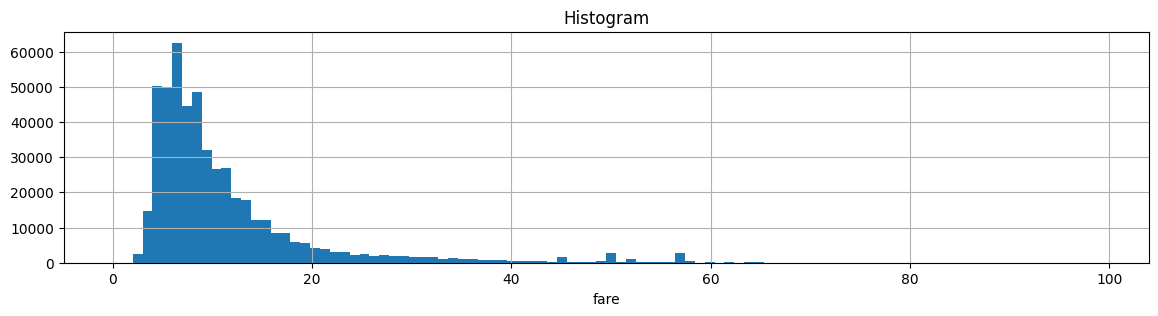

In [13]:
df_train[df_train.fare_amount<100].fare_amount.hist(bins=100, figsize=(14,3))
plt.xlabel('fare')
plt.title('Histogram')

## Remove Missing Data

In [14]:
print(df_train.isnull().sum())

key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
distance             0
dtype: int64


In [15]:
print('Old size: %d' % len(df_train))
df_train = df_train.dropna(how = 'any', axis = 'rows')
print('New size: %d' % len(df_train))

Old size: 500000
New size: 500000


## Location Data Preprocess

In [16]:
# minimum and maximum longitude test set
min(df_train.pickup_longitude.min(), df_train.dropoff_longitude.min()), \
max(df_train.pickup_longitude.max(), df_train.dropoff_longitude.max())

(-736.45, 40.853232)

In [17]:
# minimum and maximum latitude test
min(df_train.pickup_latitude.min(), df_train.dropoff_latitude.min()), \
max(df_train.pickup_latitude.max(), df_train.dropoff_latitude.max())

(-3116.285383, 3310.364462)

In [18]:
# this function will also be used with the test set below
def select_within_boundingbox(df, BB):
    return (df.pickup_longitude >= BB[0]) & (df.pickup_longitude <= BB[1]) & \
           (df.pickup_latitude >= BB[2]) & (df.pickup_latitude <= BB[3]) & \
           (df.dropoff_longitude >= BB[0]) & (df.dropoff_longitude <= BB[1]) & \
           (df.dropoff_latitude >= BB[2]) & (df.dropoff_latitude <= BB[3])

# load image of NYC map
BB = (-74.5, -72.8, 40.5, 41.8)
BB_zoom = (-74.3, -73.7, 40.5, 40.9)

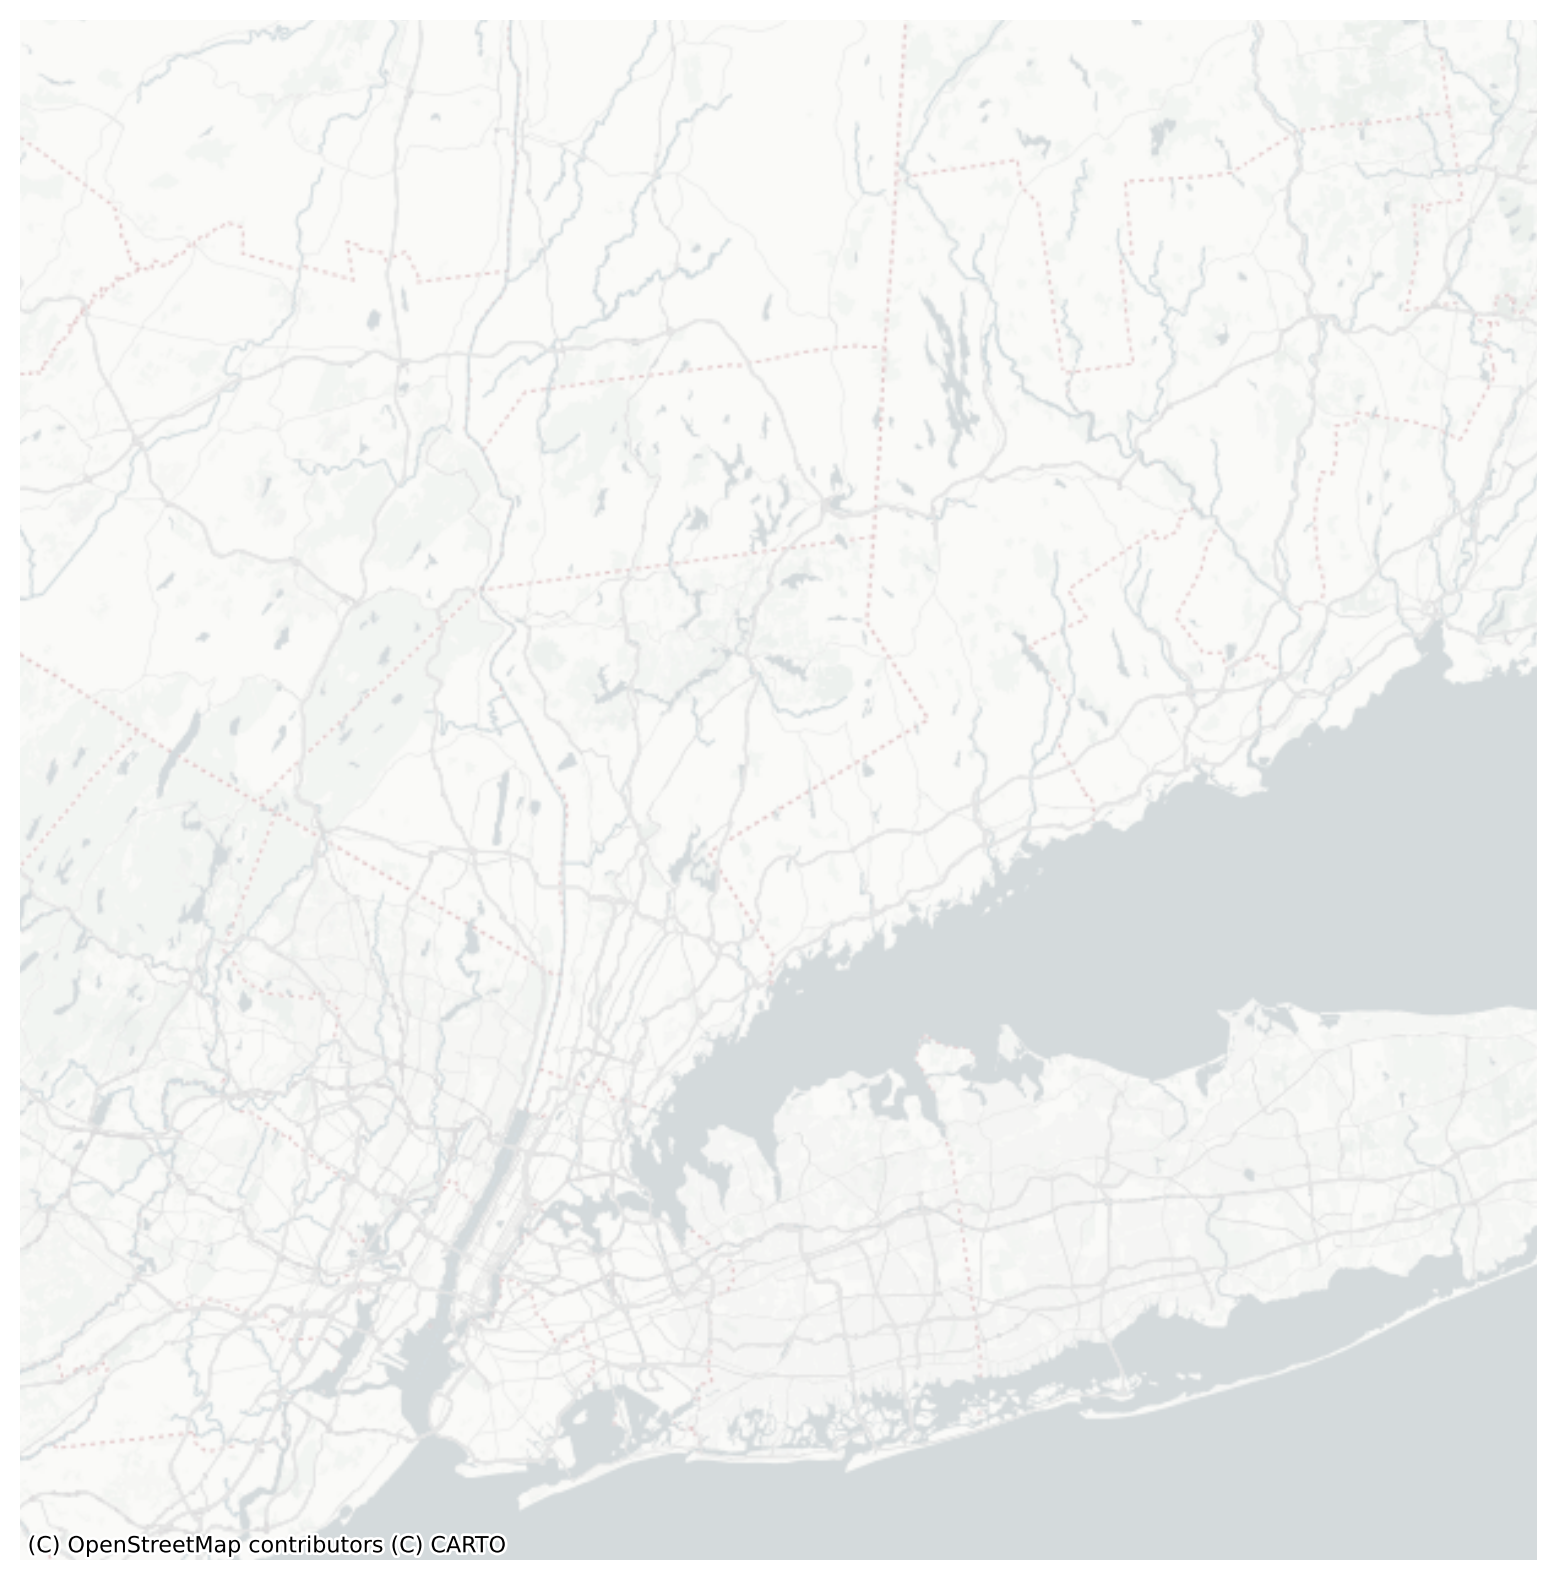

In [19]:
west, east, south, north = -74.5, -72.8, 40.5, 41.8
bbox_correct = (west, south, east, north)

# Create GeoDataFrame with correct bbox and WGS84 CRS
gdf = gpd.GeoDataFrame({"geometry":[box(*bbox_correct)]}, crs="EPSG:4326")

# Project to Web Mercator (required by most tile providers)
gdf_3857 = gdf.to_crs(epsg=3857)

# Get bounds in Web Mercator to set plot limits
minx, miny, maxx, maxy = gdf_3857.total_bounds

# Create figure sized to produce 2000x2000 pixels (figsize * dpi)
dpi = 200
figsize = (2000 / dpi, 2000 / dpi)  # (10, 10) for dpi=200

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

# Plot an invisible polygon to set extent
gdf_3857.plot(ax=ax, alpha=0)

# Add basemap (choose a provider that is available)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)

# Limit map to bbox (in Web Mercator coords)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Remove axes and save
ax.axis("off")
plt.savefig("nyc_map_2000x2000.png", bbox_inches="tight", pad_inches=0)
plt.show()

nyc_map = np.array(Image.open("nyc_map_2000x2000.png"))

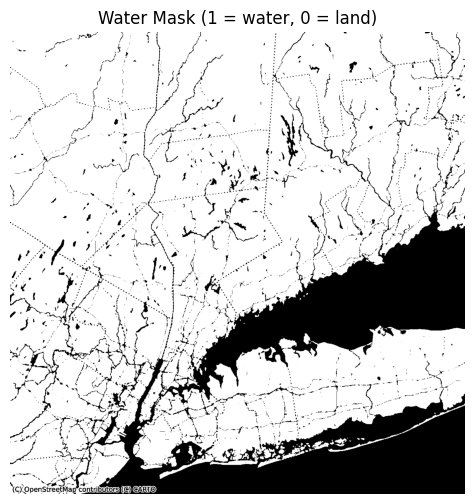

In [20]:
# Load the basemap you already saved
img = Image.open("nyc_map_2000x2000.png").convert("RGB")
arr = np.array(img)

# Compute lightness (0=black, 255=white)
lightness = arr.mean(axis=2)

# Water mask: water = 1, land = 0
# Tune threshold as needed (Positron water is very bright)
water_mask = (lightness > 230).astype(np.uint8)

# Show mask
plt.figure(figsize=(6,6))
plt.imshow(water_mask, cmap="gray")
plt.title("Water Mask (1 = water, 0 = land)")
plt.axis("off")
plt.show()

# Save mask
Image.fromarray((water_mask * 255).astype(np.uint8)).save("water_mask.png")


In [21]:
print('Old size: %d' % len(df_train))
df_train = df_train[select_within_boundingbox(df_train, BB)]
print('New size: %d' % len(df_train))

Old size: 500000
New size: 499471


In [22]:
# this function will be used more often to plot data on the NYC map
def plot_on_map(df, BB, nyc_map, s=10, alpha=0.2):
    fig, axs = plt.subplots(1, 2, figsize=(16,10))
    axs[0].scatter(df.pickup_longitude, df.pickup_latitude, zorder=1, alpha=alpha, c='r', s=s)
    axs[0].set_xlim((BB[0], BB[1]))
    axs[0].set_ylim((BB[2], BB[3]))
    axs[0].set_title('Pickup locations')
    axs[0].imshow(nyc_map, zorder=0, extent=BB)

    axs[1].scatter(df.dropoff_longitude, df.dropoff_latitude, zorder=1, alpha=alpha, c='r', s=s)
    axs[1].set_xlim((BB[0], BB[1]))
    axs[1].set_ylim((BB[2], BB[3]))
    axs[1].set_title('Dropoff locations')
    axs[1].imshow(nyc_map, zorder=0, extent=BB)

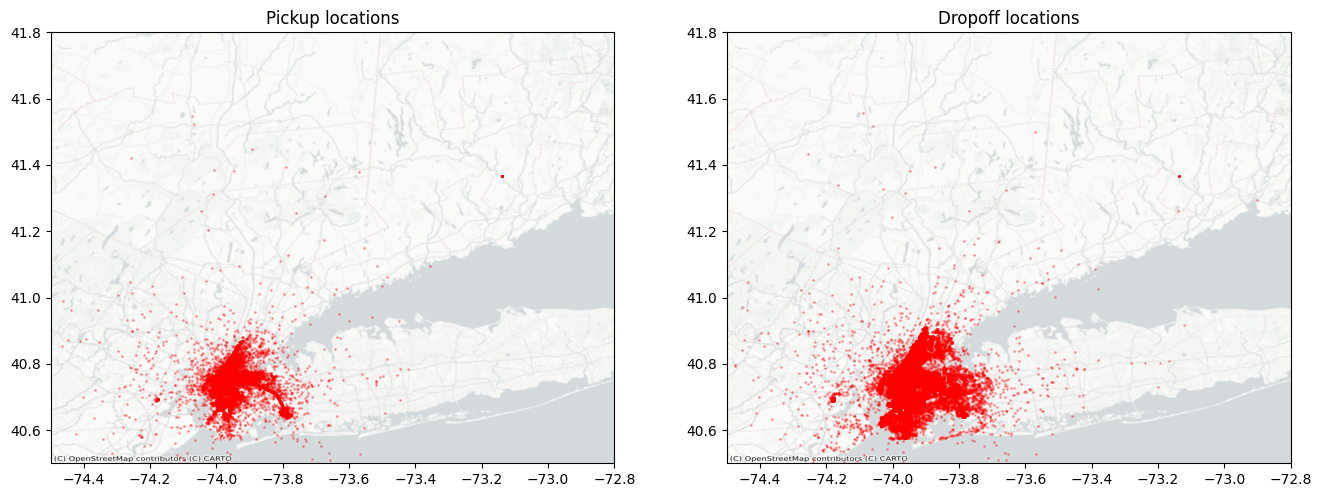

In [23]:
# plot training data on map
plot_on_map(df_train, BB, nyc_map, s=1, alpha=0.3)

In [24]:
def plot_hires(df, BB, figsize=(12, 12), ax=None, c=('r', 'b')):
    if ax == None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)

    idx = select_within_boundingbox(df, BB)
    ax.scatter(df[idx].pickup_longitude, df[idx].pickup_latitude, c=c[0], s=0.01, alpha=0.5)
    ax.scatter(df[idx].dropoff_longitude, df[idx].dropoff_latitude, c=c[1], s=0.01, alpha=0.5)

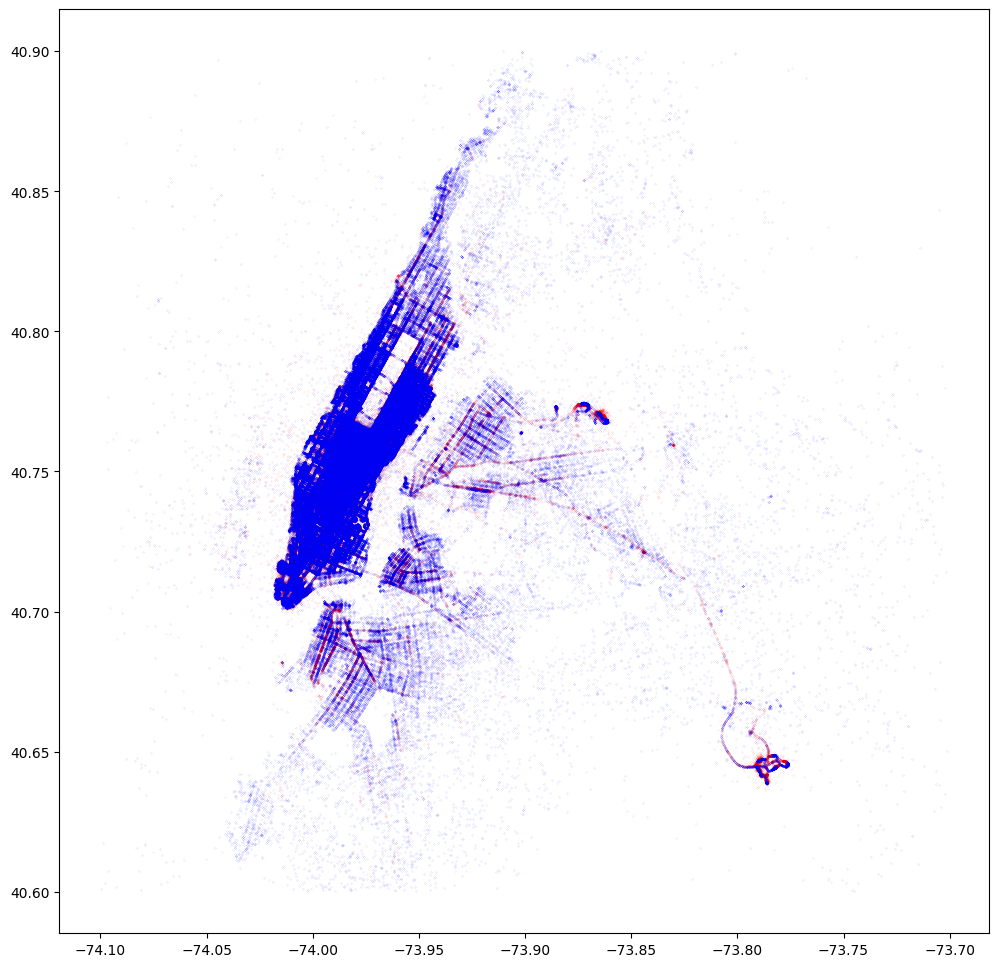

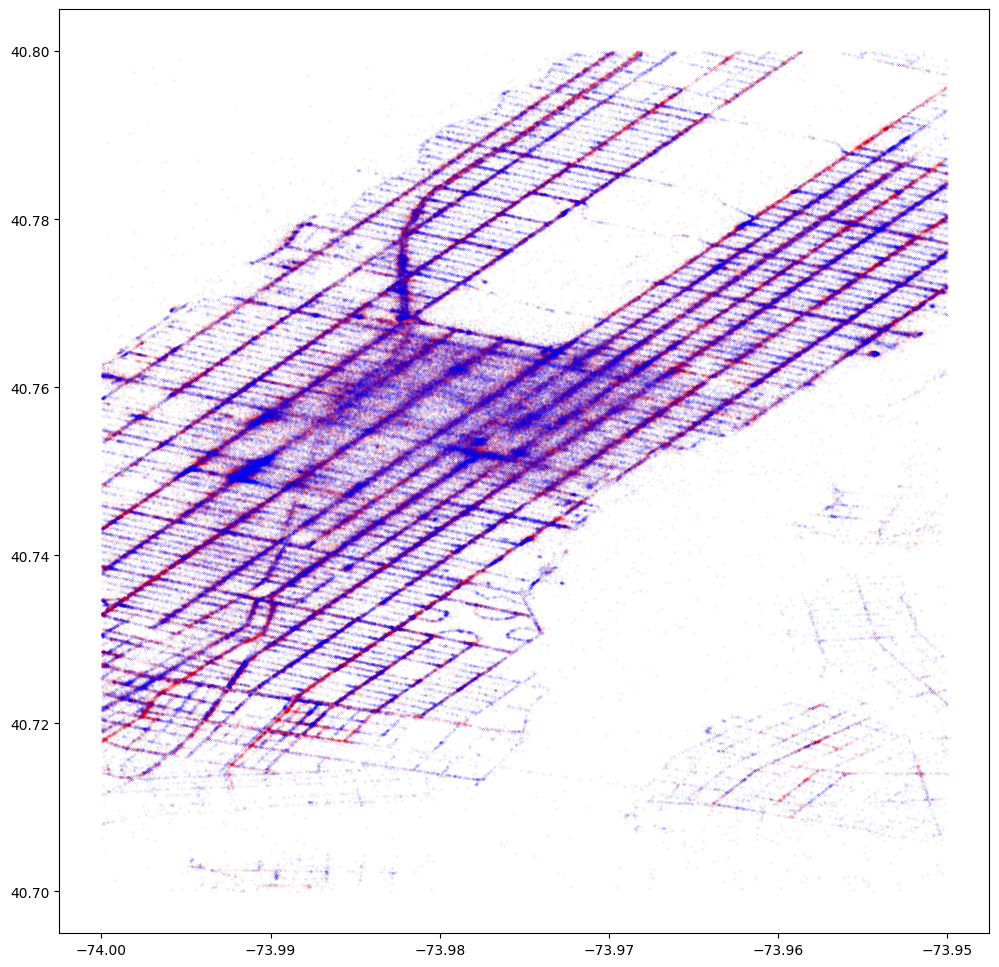

In [26]:
plot_hires(df_train, (-74.1, -73.7, 40.6, 40.9))
plot_hires(df_train, (-74, -73.95, 40.7, 40.8))

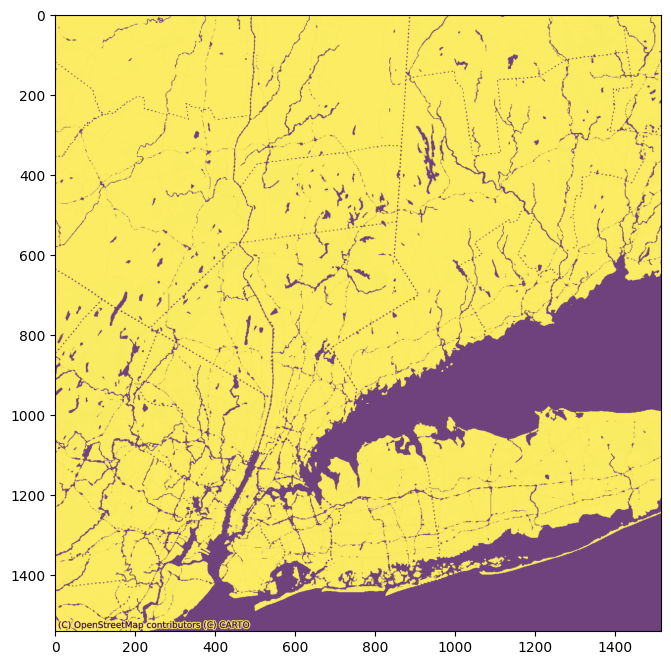

In [27]:
nyc_mask = np.array(Image.open("water_mask.png"))

plt.figure(figsize=(8,8))
plt.imshow(nyc_map, zorder=0)
plt.imshow(nyc_mask, zorder=1, alpha=0.7)

In [28]:
def lonlat_to_xy(longitude, latitude, dx, dy, BB):
    return (dx*(longitude - BB[0])/(BB[1]-BB[0])).astype('int'), \
           (dy - dy*(latitude - BB[2])/(BB[3]-BB[2])).astype('int')

In [29]:
pickup_x, pickup_y = lonlat_to_xy(df_train.pickup_longitude, df_train.pickup_latitude,
                                  nyc_mask.shape[1], nyc_mask.shape[0], BB)
dropoff_x, dropoff_y = lonlat_to_xy(df_train.dropoff_longitude, df_train.dropoff_latitude,
                                  nyc_mask.shape[1], nyc_mask.shape[0], BB)

In [30]:
idx = (nyc_mask[pickup_y, pickup_x] & nyc_mask[dropoff_y, dropoff_x])
print("Number of trips in water: {}".format(np.sum(~idx)))

Number of trips in water: 13007295


In [31]:
def remove_datapoints_from_water(df, mask_path="water_mask.png"):

    # Load the mask (single channel, 0=water, 255=land)
    mask = np.array(Image.open(mask_path))

    # Convert to boolean: True = land, False = water
    land_mask = mask > 128

    # NYC bounding box (lon_min, lon_max, lat_min, lat_max)
    BB = (-74.5, -72.8, 40.5, 41.8)

    H, W = land_mask.shape  # height, width

    # Convert longitude/latitude to pixel coordinates
    def lonlat_to_xy(lon, lat):
        x = ((lon - BB[0]) / (BB[1] - BB[0])) * W
        y = (1 - (lat - BB[2]) / (BB[3] - BB[2])) * H

        x = x.astype(int)
        y = y.astype(int)

        # clip to valid range
        x = np.clip(x, 0, W - 1)
        y = np.clip(y, 0, H - 1)
        return x, y

    # Convert pickup points
    px, py = lonlat_to_xy(df.pickup_longitude.values,
                          df.pickup_latitude.values)

    # Convert dropoff points
    dx, dy = lonlat_to_xy(df.dropoff_longitude.values,
                          df.dropoff_latitude.values)

    # Keep only trips where both pickup and dropoff are ON LAND
    on_land = land_mask[py, px] & land_mask[dy, dx]

    # Return filtered dataframe
    return df[on_land]


In [32]:
print('Old size: %d' % len(df_train))
df_train = remove_datapoints_from_water(df_train)
print('New size: %d' % len(df_train))

Old size: 499471
New size: 448462


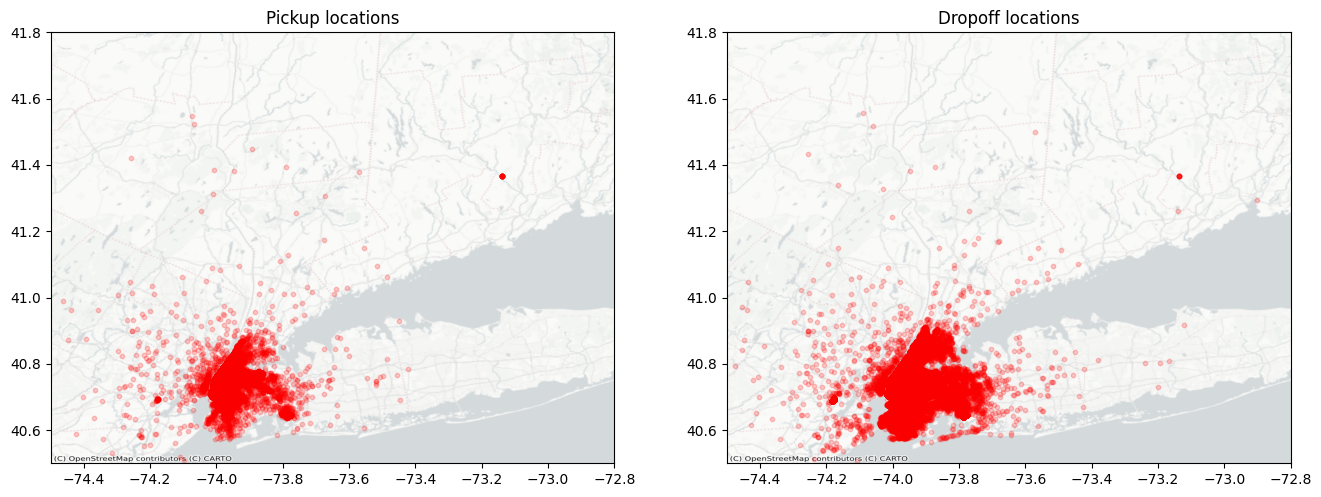

In [33]:
# plot training data
plot_on_map(df_train, BB, nyc_map)

In [34]:
# ------------------------------
# Distance function in KILOMETERS
# ------------------------------
def distance(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295  # Pi/180
    a = 0.5 - np.cos((lat2 - lat1) * p)/2 + \
        np.cos(lat1 * p) * np.cos(lat2 * p) * \
        (1 - np.cos((lon2 - lon1) * p)) / 2
    return 12742 * np.arcsin(np.sqrt(a))  # 2*R (Earth radius) but in KM


# ------------------------------
# Grid setup
# ------------------------------
n_lon, n_lat = 200, 200  # grid size
density_pickup  = np.zeros((n_lat, n_lon))
density_dropoff = np.zeros((n_lat, n_lon))

# BOUNDING BOX (same as your original)
BB = (-74.5, -72.8, 40.5, 41.8)  # west, east, south, north

# Create bins
bins_lon = np.zeros(n_lon+1)
bins_lat = np.zeros(n_lat+1)

delta_lon = (BB[1]-BB[0]) / n_lon
delta_lat = (BB[3]-BB[2]) / n_lat

# ---------------------------------------------
# NEW: bin dimensions now computed in KILOMETERS
# ---------------------------------------------
bin_width_km  = distance(BB[2], BB[1], BB[2], BB[0]) / n_lon
bin_height_km = distance(BB[3], BB[0], BB[2], BB[0]) / n_lat

# Fill bins
for i in range(n_lon+1):
    bins_lon[i] = BB[0] + i * delta_lon
for j in range(n_lat+1):
    bins_lat[j] = BB[2] + j * delta_lat


# ------------------------------
# Digitize datapoints into bins
# ------------------------------
inds_pickup_lon  = np.digitize(df_train.pickup_longitude, bins_lon)
inds_pickup_lat  = np.digitize(df_train.pickup_latitude,  bins_lat)
inds_dropoff_lon = np.digitize(df_train.dropoff_longitude, bins_lon)
inds_dropoff_lat = np.digitize(df_train.dropoff_latitude,  bins_lat)

# Area of each grid cell in **square kilometers**
dxdy = bin_width_km * bin_height_km


# ------------------------------
# Count points per grid cell
# ------------------------------
for i in range(n_lon):
    for j in range(n_lat):

        density_pickup[j, i] = (
            np.sum((inds_pickup_lon == i+1) &
                   (inds_pickup_lat == (n_lat - j)))
        ) / dxdy

        density_dropoff[j, i] = (
            np.sum((inds_dropoff_lon == i+1) &
                   (inds_dropoff_lat == (n_lat - j)))
        ) / dxdy


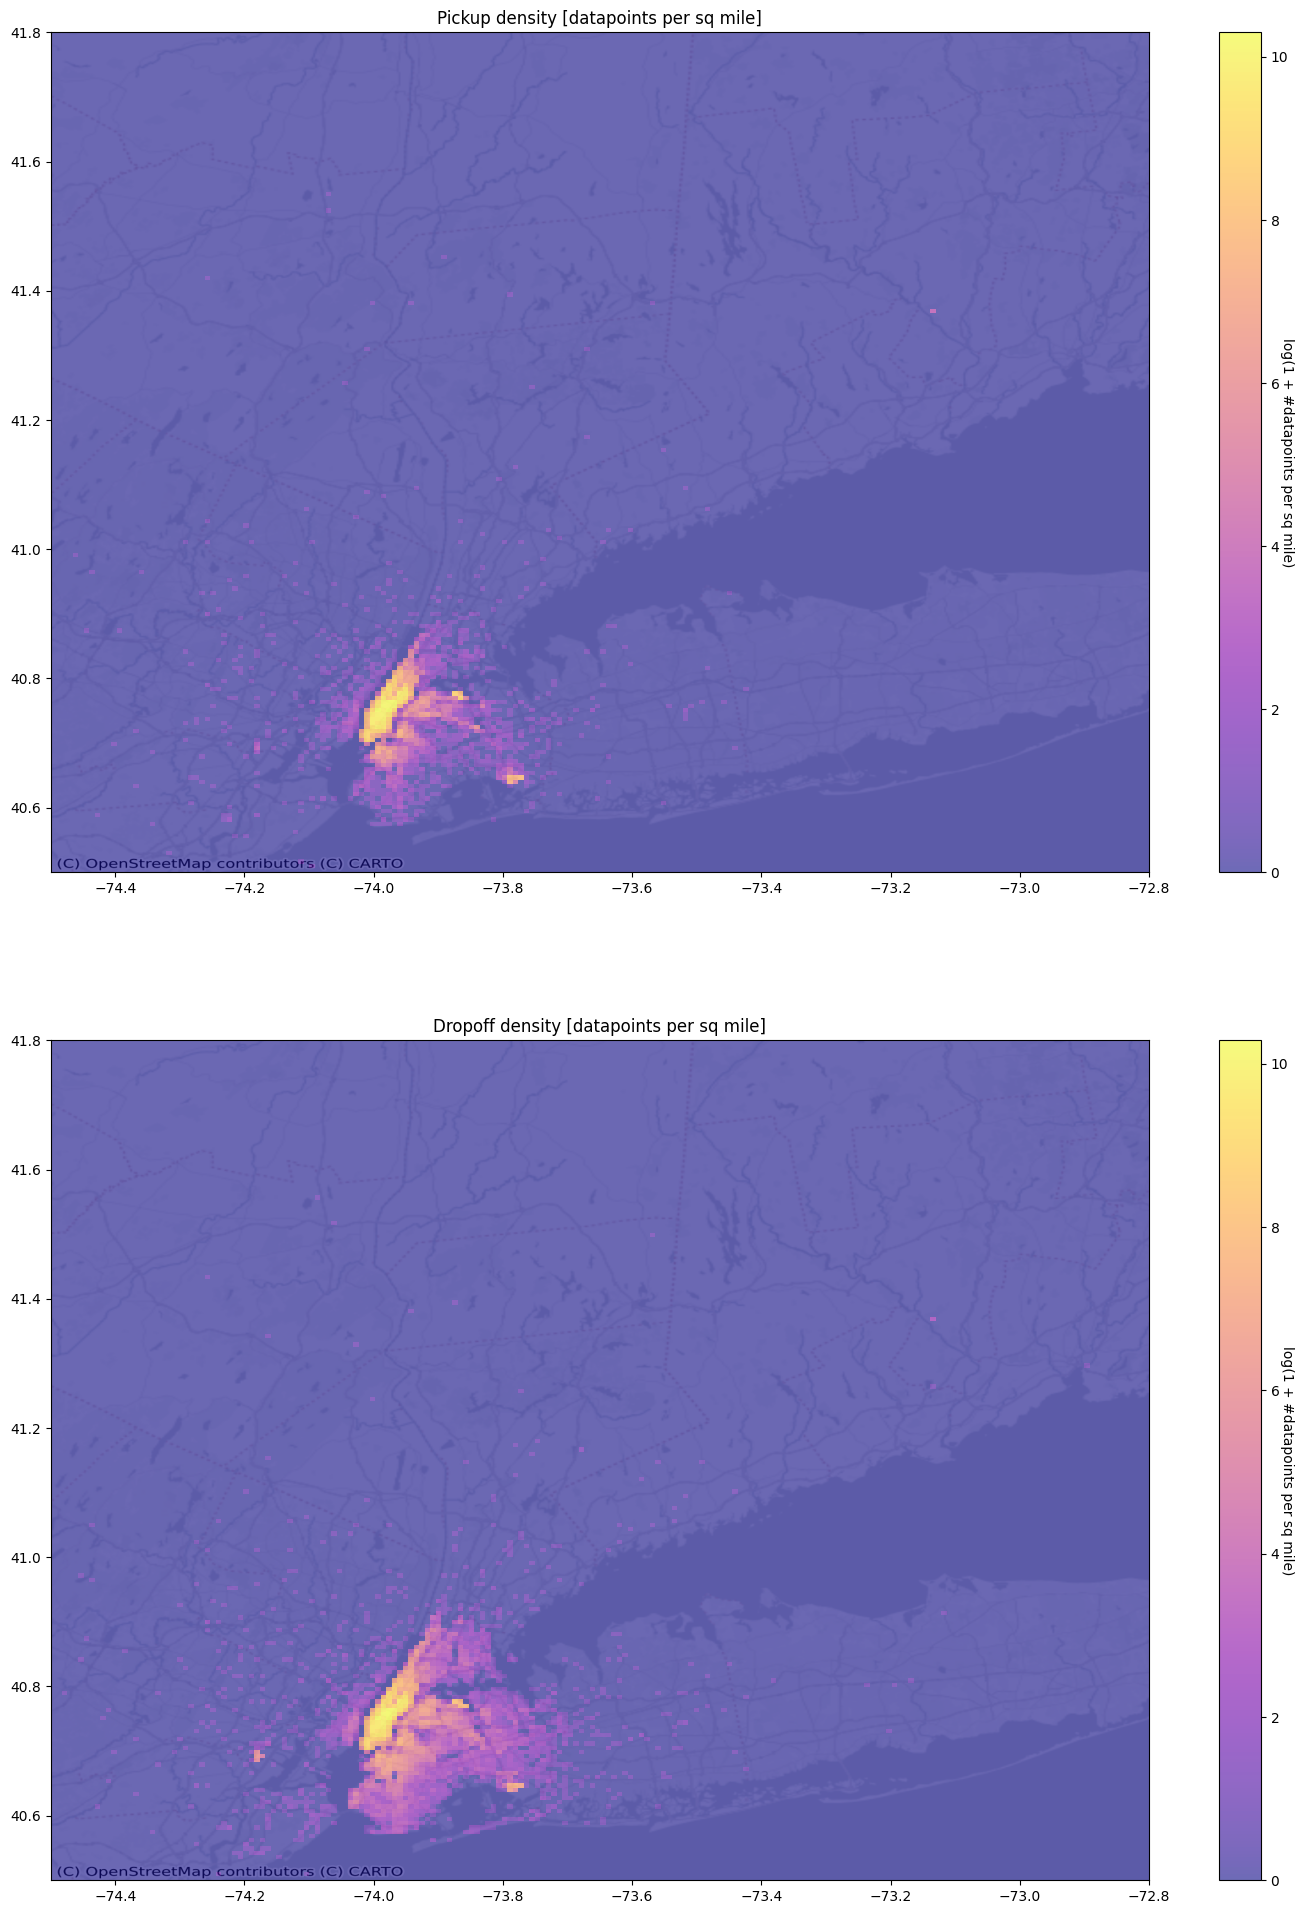

In [35]:
# Plot the density arrays
fig, axs = plt.subplots(2, 1, figsize=(18, 24))
axs[0].imshow(nyc_map, zorder=0, extent=BB);
im = axs[0].imshow(np.log1p(density_pickup), zorder=1, extent=BB, alpha=0.6, cmap='plasma')
axs[0].set_title('Pickup density [datapoints per sq mile]')
cbar = fig.colorbar(im, ax=axs[0])
cbar.set_label('log(1 + #datapoints per sq mile)', rotation=270)

axs[1].imshow(nyc_map, zorder=0, extent=BB);
im = axs[1].imshow(np.log1p(density_dropoff), zorder=1, extent=BB, alpha=0.6, cmap='plasma')
axs[1].set_title('Dropoff density [datapoints per sq mile]')
cbar = fig.colorbar(im, ax=axs[1])
cbar.set_label('log(1 + #datapoints per sq mile)', rotation=270)

In [36]:
# add time information
df_train['year'] = df_train.pickup_datetime.apply(lambda t: t.year)
df_train['weekday'] = df_train.pickup_datetime.apply(lambda t: t.weekday())
df_train['hour'] = df_train.pickup_datetime.apply(lambda t: t.hour)

,distance_kilometer
count,448462.000000
mean,3.213210
std,3.437038
min,0.000072
25%,1.253550
50%,2.125157
75%,3.818572
max,104.254968


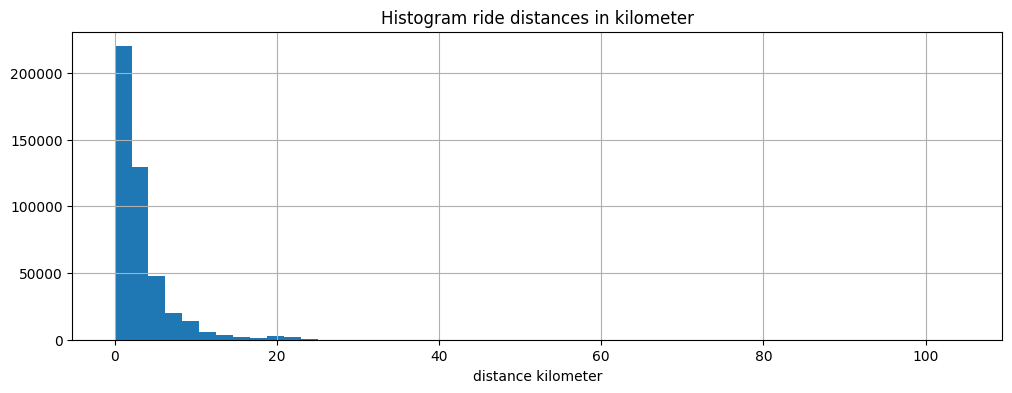

In [37]:
# add new column to dataframe with distance in miles
df_train['distance_kilometer'] = distance(df_train.pickup_latitude, df_train.pickup_longitude, \
                                      df_train.dropoff_latitude, df_train.dropoff_longitude)

df_train.distance_kilometer.hist(bins=50, figsize=(12,4))
plt.xlabel('distance kilometer')
plt.title('Histogram ride distances in kilometer')
df_train.distance_kilometer.describe()

In [38]:
# remove datapoints with distance <0.1 kilometer
idx = (df_train.distance_kilometer >= 0.1)
print('Old size: %d' % len(df_train))
df_train = df_train[idx]
print('New size: %d' % len(df_train))

Old size: 448462
New size: 445891


In [39]:
# JFK airport coordinates, see https://www.travelmath.com/airport/JFK


def plot_location_fare(loc, name, range=1.5):
    # select all datapoints with dropoff location within range of airport
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    idx = (distance(df_train.pickup_latitude, df_train.pickup_longitude, loc[1], loc[0]) < range)
    df_train[idx].fare_amount.hist(bins=100, ax=axs[0])
    axs[0].set_xlabel('fare')
    axs[0].set_title('Histogram pickup location within {} miles of {}'.format(range, name))

    idx = (distance(df_train.dropoff_latitude, df_train.dropoff_longitude, loc[1], loc[0]) < range)
    df_train[idx].fare_amount.hist(bins=100, ax=axs[1])
    axs[1].set_xlabel('fare')
    axs[1].set_title('Histogram dropoff location within {} miles of {}'.format(range, name))



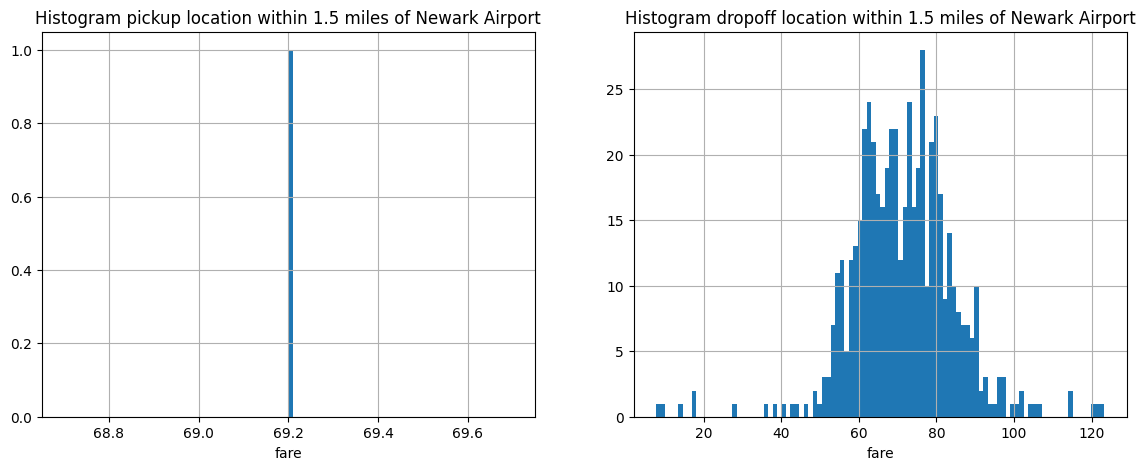

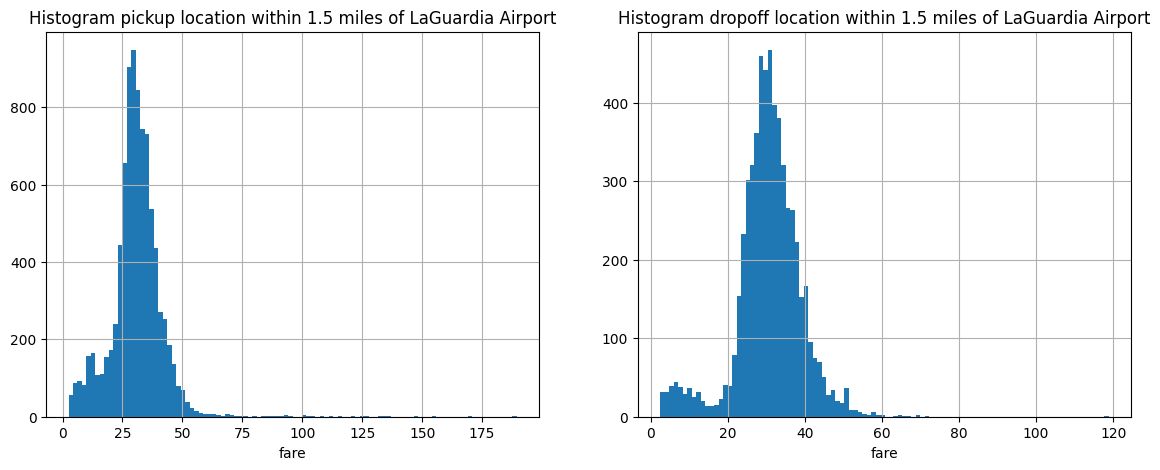

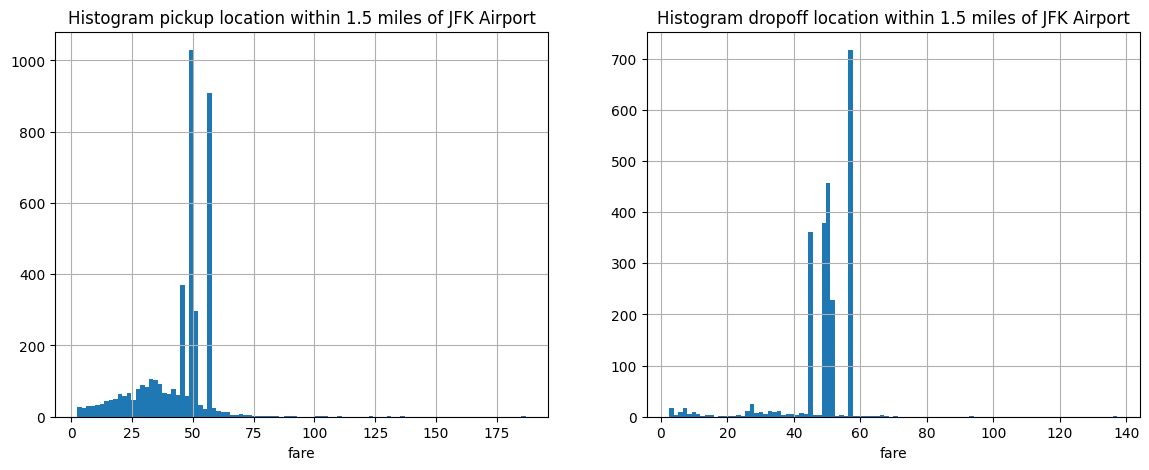

In [40]:
ewr = (-74.175, 40.69) # Newark Liberty International Airport, see https://www.travelmath.com/airport/EWR
lgr = (-73.87, 40.77) # LaGuardia Airport, see https://www.travelmath.com/airport/LGA
jfk = (-73.7822222222, 40.6441666667)
nyc = (-74.0063889, 40.7141667)
plot_location_fare(ewr, 'Newark Airport')
plot_location_fare(lgr, 'LaGuardia Airport')
plot_location_fare(jfk, 'JFK Airport')

In [41]:
df_train['fare_per_kilometer'] = df_train.fare_amount / df_train.distance_kilometer
df_train.fare_per_kilometer.describe()

,fare_per_kilometer
count,445891.000000
mean,4.581999
std,6.180045
min,0.028073
25%,2.987279
50%,3.840515
75%,5.062157
max,1024.466448


In [42]:
# idx = (df_train.distance_kilometer < 3) & (df_train.fare_amount < 100)
# plt.scatter(df_train[idx].distance_kilometer, df_train[idx].fare_per_distance_kilometer)
# plt.xlabel('distance distance_kilometer')
# plt.ylabel('fare per distance distance_kilometer')

# # theta here is estimated by hand
# theta = (16, 4.0)
# x = np.linspace(0.1, 3, 50)
# plt.plot(x, theta[0]/x + theta[1], '--', c='r', lw=2);

Text(0, 0.5, 'Fare / kilo')

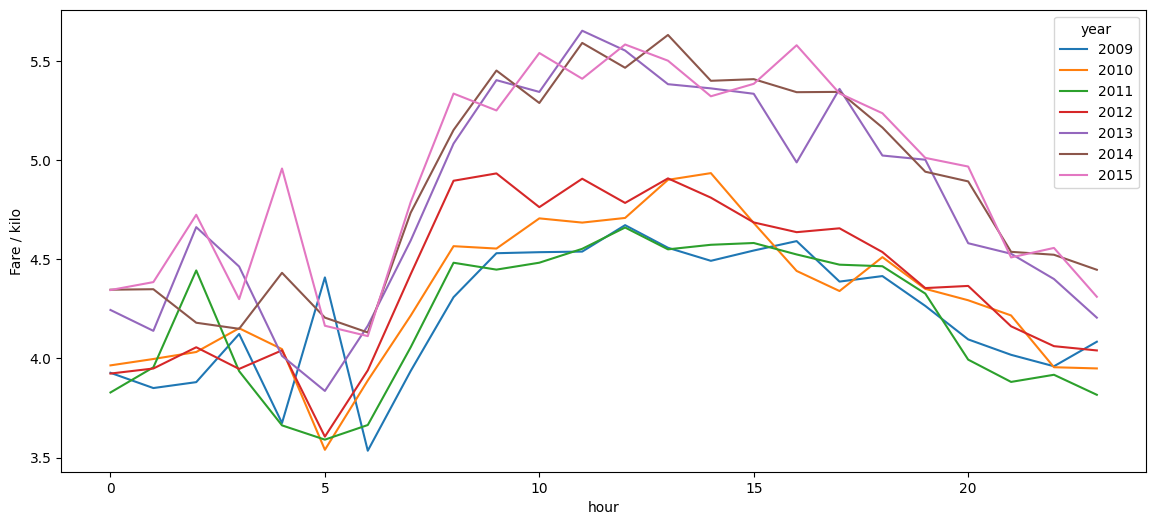

In [43]:
df_train.pivot_table('fare_per_kilometer', index='hour', columns='year').plot(figsize=(14,6))
plt.ylabel('Fare / kilo')

In [44]:
df_train

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance,year,weekday,hour,distance_kilometer,fare_per_kilometer
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,1.030764,2009,0,17,1.030764,4.365694
1,2012-04-08 07:30:50.0000002,5.3,2012-04-08 07:30:50+00:00,-73.996335,40.737142,-73.980721,40.733559,1,1.374577,2012,6,7,1.374577,3.855732
2,2011-04-05 17:11:05.0000001,7.7,2011-04-05 17:11:05+00:00,-74.001821,40.737547,-73.998060,40.722788,2,1.671445,2011,1,17,1.671445,4.606793
3,2009-07-22 16:08:00.000000163,5.3,2009-07-22 16:08:00+00:00,-73.981060,40.737690,-73.994177,40.728412,1,1.511904,2009,2,16,1.511904,3.505513
4,2011-06-28 19:47:00.000000168,4.5,2011-06-28 19:47:00+00:00,-73.988893,40.760160,-73.986445,40.757857,3,0.328771,2011,1,19,0.328771,13.687345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499993,2009-04-24 07:22:49.0000001,4.9,2009-04-24 07:22:49+00:00,-73.988965,40.736834,-73.992982,40.746907,1,1.170077,2009,4,7,1.170077,4.187760
499994,2011-09-05 14:12:00.000000162,22.5,2011-09-05 14:12:00+00:00,-73.945985,40.777370,-73.983530,40.703027,1,8.851082,2011,0,14,8.851082,2.542062
499996,2014-04-24 22:42:04.0000001,14.0,2014-04-24 22:42:04+00:00,-73.948121,40.774575,-73.964452,40.758017,1,2.298143,2014,3,22,2.298143,6.091876
499998,2012-04-17 11:54:00.000000158,13.7,2012-04-17 11:54:00+00:00,-73.866067,40.770737,-73.924127,40.752557,3,5.291344,2012,1,11,5.291344,2.589134


In [45]:
# -----------------------------
# 2. Feature Engineering
# -----------------------------

# Convert pickup_datetime to datetime

df_train["day_of_week"] = df_train["pickup_datetime"].dt.dayofweek

# Calculate distance (Haversine)
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # km

# -----------------------------
# 3. Select features and target
# -----------------------------
features = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
    "year",
    "weekday",
    "day_of_week",
    "hour",
    "distance_kilometer"
]


X = df_train[features]
y = df_train["fare_amount"]

# -----------------------------
# 4. Train-test split (80 / 20)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5. Train Random Forest
# -----------------------------
# model = RandomForestRegressor(
#     n_estimators=200,        # reduce trees to save RAM
#     max_depth=10,     # limit depth
#     min_samples_split=10,
#     min_samples_leaf=10,
#     n_jobs=-1,             # use all cores efficiently
#     random_state=42
# )


# model.fit(X_train, y_train)

# # -----------------------------
# # 6. Predict & Evaluate
# # -----------------------------

# y_train_pred = model.predict(X_train)
# y_test_pred  = model.predict(X_test)

# rmse_train = root_mean_squared_error(y_train, y_train_pred)
# rmse_test  = root_mean_squared_error(y_test, y_test_pred)

# print("Train RMSE:", rmse_train)
# print("Test RMSE:", rmse_test)

# Example prediction
# print("Example predictions:", y_pred[:5])

In [46]:
# add dummy variable (bias term)
def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack([ones, X])

In [47]:
def closed_form_ridge(X, y, alpha):
    n_features = X.shape[1]
    I = np.eye(n_features)
    I[0,0] = 0  # Do NOT regularize bias

    XT = X.T
    W = np.linalg.inv(XT @ X + alpha * I) @ (XT @ y)
    return W

In [48]:
class BOA:
    def __init__(self, func, dim, n_pop=20, max_iter=100, p=0.8, c=0.1):
        """
        func: objective function to minimize
        dim: dimensionality of the problem
        n_pop: number of butterflies
        max_iter: maximum iterations
        p: probability switch between global and local search
        c: sensory modality (step size)
        """
        self.func = func
        self.dim = dim
        self.n_pop = n_pop
        self.max_iter = max_iter
        self.p = p
        self.c = c

    def initialize(self, lb=-10, ub=10):
        self.lb = lb
        self.ub = ub
        self.population = np.random.uniform(lb, ub, (self.n_pop, self.dim))
        self.fitness = np.array([self.func(ind) for ind in self.population])
        best_idx = np.argmin(self.fitness)
        self.best = self.population[best_idx].copy()
        self.best_fitness = self.fitness[best_idx]

    def move_global(self):
        r = np.random.rand(self.n_pop, self.dim)
        self.population += self.c * r * (self.best - self.population)

    def move_local(self):
        r = np.random.rand(self.n_pop, self.dim)
        j = np.random.randint(0, self.n_pop, self.n_pop)
        k = np.random.randint(0, self.n_pop, self.n_pop)
        self.population += self.c * r * (self.population[j] - self.population[k])

    def optimize(self):
        self.initialize()

        self.history = []   # store best fitness at each iteration

        # tqdm progress bar
        pbar = tqdm(range(self.max_iter), desc="BOA Optimizing")

        for t in pbar:
            for i in range(self.n_pop):
                if np.random.rand() < self.p:
                    self.move_global()
                else:
                    self.move_local()

            # keep in bounds
            self.population = np.clip(self.population, self.lb, self.ub)

            # evaluate
            self.fitness = np.array([self.func(ind) for ind in self.population])

            # update best
            best_idx = np.argmin(self.fitness)
            if self.fitness[best_idx] < self.best_fitness:
                self.best_fitness = self.fitness[best_idx]
                self.best = self.population[best_idx].copy()

            # save history
            self.history.append(self.best_fitness)

            # update progress bar text
            pbar.set_postfix({"Best RMSE": f"{self.best_fitness:.4f}"})

        return self.best, self.best_fitness, self.history



In [49]:
def mutate(position, mutation_rate, lb, ub):
    # Gaussian mutation
    new_pos = position + mutation_rate * np.random.randn(len(position))
    return np.clip(new_pos, lb, ub)


In [50]:
def LSAM(best, best_fit, population, fitness, func,
         lb, ub, num_iterations=20, mutation_rate=0.1):

    g = best.copy()
    g_fit = best_fit

    n_pop = len(population)

    for _ in range(num_iterations):

        # 1. Mutate best solution
        new_pos = mutate(g, mutation_rate, lb, ub)
        new_fit = func(new_pos)

        if new_fit < g_fit:
            g = new_pos
            g_fit = new_fit
        else:
            # 2. Otherwise mutate a random solution
            idx = np.random.randint(0, n_pop)
            p = population[idx]
            p_fit = fitness[idx]

            if new_fit < p_fit:
                population[idx] = new_pos
                fitness[idx] = new_fit

    return g, g_fit, population, fitness


In [51]:
class DBOA:
    def __init__(self, func, dim, n_pop=20, max_iter=100,
                 p=0.8, c=0.1,
                 lsam_iters=20, mutation_rate=0.1):
        self.func = func
        self.dim = dim
        self.n_pop = n_pop
        self.max_iter = max_iter
        self.p = p
        self.c = c
        self.lsam_iters = lsam_iters
        self.mutation_rate = mutation_rate

    def initialize(self, lb=-10, ub=10):
        self.lb = lb
        self.ub = ub

        self.population = np.random.uniform(lb, ub, (self.n_pop, self.dim))
        self.fitness = np.array([self.func(ind) for ind in self.population])

        best_idx = np.argmin(self.fitness)
        self.best = self.population[best_idx].copy()
        self.best_fitness = self.fitness[best_idx]

    def move_global(self):
        r = np.random.rand(self.n_pop, self.dim)
        self.population += self.c * r * (self.best - self.population)

    def move_local(self):
        r = np.random.rand(self.n_pop, self.dim)
        j = np.random.randint(0, self.n_pop, self.n_pop)
        k = np.random.randint(0, self.n_pop, self.n_pop)
        self.population += self.c * r * (self.population[j] - self.population[k])

    def optimize(self):
        self.initialize()
        self.history = []

        pbar = tqdm(range(self.max_iter), desc="DBOA Optimizing")

        for t in pbar:

            # standard BOA movement
            for _ in range(self.n_pop):
                if np.random.rand() < self.p:
                    self.move_global()
                else:
                    self.move_local()

            # bound check
            self.population = np.clip(self.population, self.lb, self.ub)

            # evaluate
            self.fitness = np.array([self.func(ind) for ind in self.population])

            # update best
            best_idx = np.argmin(self.fitness)
            if self.fitness[best_idx] < self.best_fitness:
                self.best_fitness = self.fitness[best_idx]
                self.best = self.population[best_idx].copy()

            # ---------- APPLY LSAM HERE ----------
            self.best, self.best_fitness, self.population, self.fitness = LSAM(
                self.best,
                self.best_fitness,
                self.population,
                self.fitness,
                self.func,
                self.lb, self.ub,
                num_iterations=self.lsam_iters,
                mutation_rate=self.mutation_rate
            )
            # -------------------------------------

            self.history.appe


In [52]:
def lr_objective(params):
    alpha = np.clip(params[0], 1e-6, 1000)

    # add bias column
    X_train_bias = add_bias(X_train.values)
    X_val_bias   = add_bias(X_test.values)

    W = closed_form_ridge(X_train_bias, y_train.values.reshape(-1,1), alpha)

    y_pred = X_val_bias @ W
    return root_mean_squared_error(y_test, y_pred)

In [57]:
boa = BOA(
    func=lr_objective,
    dim=1,          # only 1 hyperparameter (alpha)
    n_pop=20,
    max_iter=200,
    p=0.7,
    c=0.5
)

best_alpha, best_rmse, hist = boa.optimize()

print("\nBest Alpha:", best_alpha)
print("Best RMSE:", best_rmse)

BOA Optimizing: 100%|██████████| 200/200 [02:32<00:00,  1.31it/s, Best RMSE=4.4024]


Best Alpha: [0.0019415]
Best RMSE: 4.402379993785022


In [54]:
# final model using best alpha
alpha_final = float(best_alpha[0])

X_train_bias = add_bias(X_train.values)
X_test_bias  = add_bias(X_test.values)

W_final = closed_form_ridge(X_train_bias, y_train.values.reshape(-1,1), alpha_final)

final_pred = X_test_bias @ W_final
final_rmse = root_mean_squared_error(y_test, final_pred)

print("Final RMSE (Closed-form Ridge + BOA):", final_rmse)

Final RMSE (Closed-form Ridge + BOA): 4.402381961611795


In [55]:
lr = LinearRegression()          # you can also add parameters like fit_intercept=False if needed
lr.fit(X_train, y_train)

# 3. Make predictions
y_train_pred = lr.predict(X_train)
y_test_pred  = lr.predict(X_test)

# 4. Evaluate the model
print("=== Linear Regression Results ===")
print(f"Training R² : {r2_score(y_train, y_train_pred):.4f}")
print(f"Test     R² : {r2_score(y_test,  y_test_pred):.4f}")
print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"Test     RMSE: {np.sqrt(mean_squared_error(y_test,  y_test_pred)):.4f}")
print(f"Training MAE : {mean_absolute_error(y_train, y_train_pred):.4f}")
print(f"Test     MAE : {mean_absolute_error(y_test,  y_test_pred):.4f}")

# 5. Show coefficients and intercept
print("\nCoefficients:")
for feature, coef in zip(X.columns if hasattr(X, 'columns') else range(X.shape[1]), lr.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercept: {lr.intercept_:.4f}")

=== Linear Regression Results ===
Training R² : 0.7682
Test     R² : 0.7590
Training RMSE: 4.2798
Test     RMSE: 4.4024
Training MAE : 2.1274
Test     MAE : 2.1613

Coefficients:
  pickup_longitude: 9.8434
  pickup_latitude: -5.6918
  dropoff_longitude: -3.3569
  dropoff_latitude: -11.5800
  passenger_count: 0.0466
  year: 0.5122
  weekday: -0.0318
  day_of_week: -0.0318
  hour: 0.0099
  distance_kilometer: 2.1950
Intercept: 157.2178
